# CNN Image Classification — FashionMNIST + Custom Phone Photos
**ID:** 190110 (replace with your own student ID everywhere)

This notebook:
1. Clones your GitHub repo (custom photos live there)
2. Trains a CNN on FashionMNIST
3. Saves the trained weights as a `.pth` file
4. Tests the model on your own smartphone photos
5. Produces all required plots (loss/accuracy curves, confusion matrix, prediction gallery, error analysis)

> Replace `YOUR_USERNAME/YOUR_REPO` below with your actual GitHub repo URL before running.


In [3]:
# STEP 1: Clone your GitHub repo (contains your dataset/ folder with 10 phone photos)
!git clone https://github.com/thrafid/cnn-fashion-classification.git
%cd cnn-fashion-classification
!ls dataset

Cloning into 'cnn-fashion-classification'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 6.91 MiB | 817.00 KiB/s, done.
/content/cnn-fashion-classification/cnn-fashion-classification
bag1.png  shirt1.png   shirt3.jpeg    sneaker2.png   trouser1.jpeg
bag2.png  shirt2.jpeg  sneaker1.jpeg  sneaker3.jpeg  trouser2.jpeg


In [4]:
# STEP 2: Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## Step 3: Data Preprocessing — Transforms + Standard Dataset (FashionMNIST)

In [5]:
# FashionMNIST images are 28x28 grayscale, pixel values 0-255
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # single channel mean/std for grayscale
])

train_data = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
val_data   = datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print('Train size:', len(train_data), '| Val size:', len(val_data))

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.97MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 147kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]

Train size: 60000 | Val size: 10000


In [6]:
# STEP 4: DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False)

## Step 5: CNN Model Architecture

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 1 -> 16 channels
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16 -> 32 channels
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.fc1   = nn.Linear(32 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 28x28 -> 14x14
        x = self.pool(self.relu(self.conv2(x)))   # 14x14 -> 7x7
        x = x.view(x.size(0), -1)                 # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN(num_classes=10).to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Step 6: Training Loop (this is where the `.pth` file is created — it doesn't exist until you train)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # ---- Training ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

Epoch 1/10 | Train Loss: 0.1144 Acc: 0.9571 | Val Loss: 0.2706 Acc: 0.9139
Epoch 2/10 | Train Loss: 0.1019 Acc: 0.9618 | Val Loss: 0.2656 Acc: 0.9161
Epoch 3/10 | Train Loss: 0.0917 Acc: 0.9655 | Val Loss: 0.2841 Acc: 0.9172
Epoch 4/10 | Train Loss: 0.0801 Acc: 0.9703 | Val Loss: 0.3296 Acc: 0.9123
Epoch 5/10 | Train Loss: 0.0704 Acc: 0.9740 | Val Loss: 0.3014 Acc: 0.9196
Epoch 6/10 | Train Loss: 0.0655 Acc: 0.9749 | Val Loss: 0.3376 Acc: 0.9130
Epoch 7/10 | Train Loss: 0.0576 Acc: 0.9784 | Val Loss: 0.3935 Acc: 0.9122
Epoch 8/10 | Train Loss: 0.0523 Acc: 0.9808 | Val Loss: 0.3519 Acc: 0.9204
Epoch 9/10 | Train Loss: 0.0457 Acc: 0.9835 | Val Loss: 0.3759 Acc: 0.9199
Epoch 10/10 | Train Loss: 0.0412 Acc: 0.9851 | Val Loss: 0.3980 Acc: 0.9123


In [15]:
torch.save(model.state_dict(), '220117.pth')
print("Saved 220117.pth — now move/upload this file into your repo's model/ folder on GitHub")

Saved 220117.pth — now move/upload this file into your repo's model/ folder on GitHub


**Where does the `.pth` file come from?**
It is NOT something you download — `torch.save(model.state_dict(), '190110.pth')` *creates* it locally in Colab after training finishes. After running the cell above, look in the Colab file browser (left sidebar, folder icon) for `190110.pth`. Download it from there, then upload it to the `model/` folder in your GitHub repo (or push it via `git add`, `git commit`, `git push` if you cloned with write access).

## Step 7: Training History Plots (Loss & Accuracy vs Epoch)

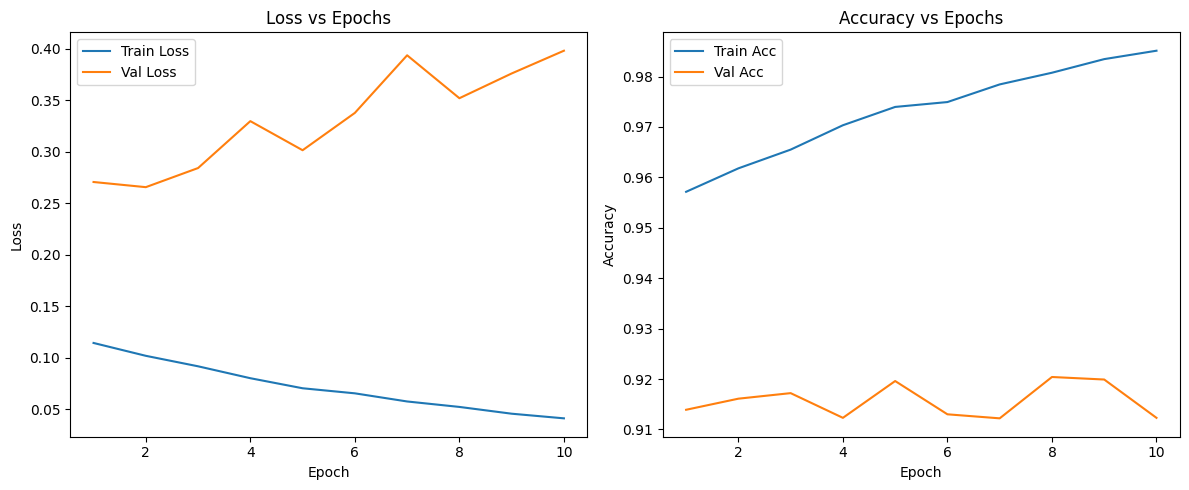

In [16]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

## Step 8: Confusion Matrix on the Standard Test Set

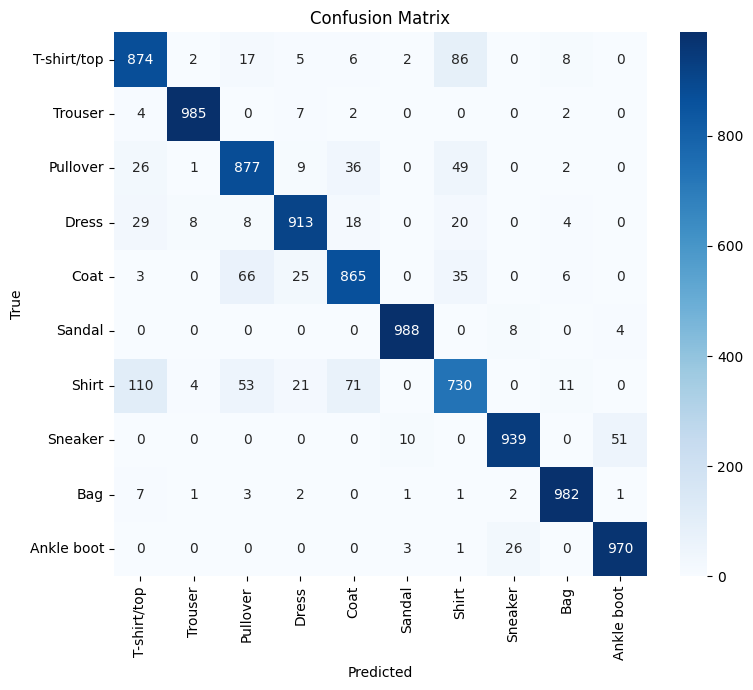

In [17]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

## Step 9: Visual Error Analysis — 3 Random Misclassified Test Images

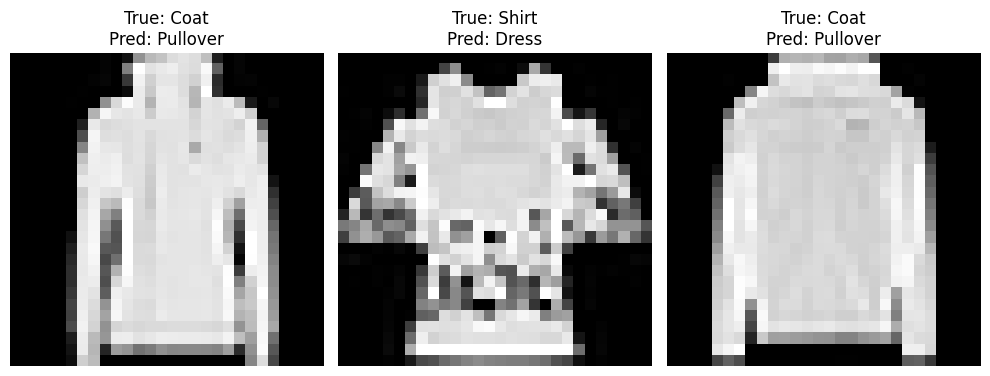

In [18]:
wrong_idx = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]
sample_wrong = random.sample(wrong_idx, 3)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, idx in zip(axes, sample_wrong):
    img, true_label = val_data[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'True: {class_names[true_label]}\nPred: {class_names[all_preds[idx]]}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('error_analysis.png')
plt.show()

## Step 10: Real-World Prediction — Your Custom Phone Photos
Put your 10 photos in the repo's `dataset/` folder (already cloned in Step 1). Update the filenames below to match yours.

In [27]:
custom_files = [
    'dataset/shirt1.png',
    'dataset/trouser1.jpeg',
    'dataset/sneaker1.jpeg',
    'dataset/bag1.png',
    'dataset/sneaker2.png',
    'dataset/bag2.png',
    'dataset/sneaker3.jpeg',
    'dataset/shirt2.jpeg',
    'dataset/shirt3.jpeg',
    'dataset/trouser2.jpeg',
]

model.eval()
results = []

for path in custom_files:
    if not os.path.exists(path):
        print(f'Missing file, skipping: {path}')
        continue
    img = Image.open(path).convert('L')          # convert to grayscale (match FashionMNIST)
    img_t = transform(img).unsqueeze(0).to(device)  # same transform pipeline as training

    with torch.no_grad():
        output = model(img_t)
        probs = torch.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    results.append((path, img, class_names[pred.item()], conf.item() * 100))
    print(f'{path}: Pred = {class_names[pred.item()]} ({conf.item()*100:.1f}%)')

dataset/shirt1.png: Pred = Shirt (49.2%)
dataset/trouser1.jpeg: Pred = Bag (100.0%)
dataset/sneaker1.jpeg: Pred = Bag (87.0%)
dataset/bag1.png: Pred = Bag (84.6%)
dataset/sneaker2.png: Pred = Sandal (100.0%)
dataset/bag2.png: Pred = Bag (98.9%)
dataset/sneaker3.jpeg: Pred = Sandal (99.4%)
dataset/shirt2.jpeg: Pred = Bag (100.0%)
dataset/shirt3.jpeg: Pred = Bag (99.7%)
dataset/trouser2.jpeg: Pred = Bag (98.9%)


## Step 11: Custom Prediction Gallery (grid of your 10 photos with predictions)

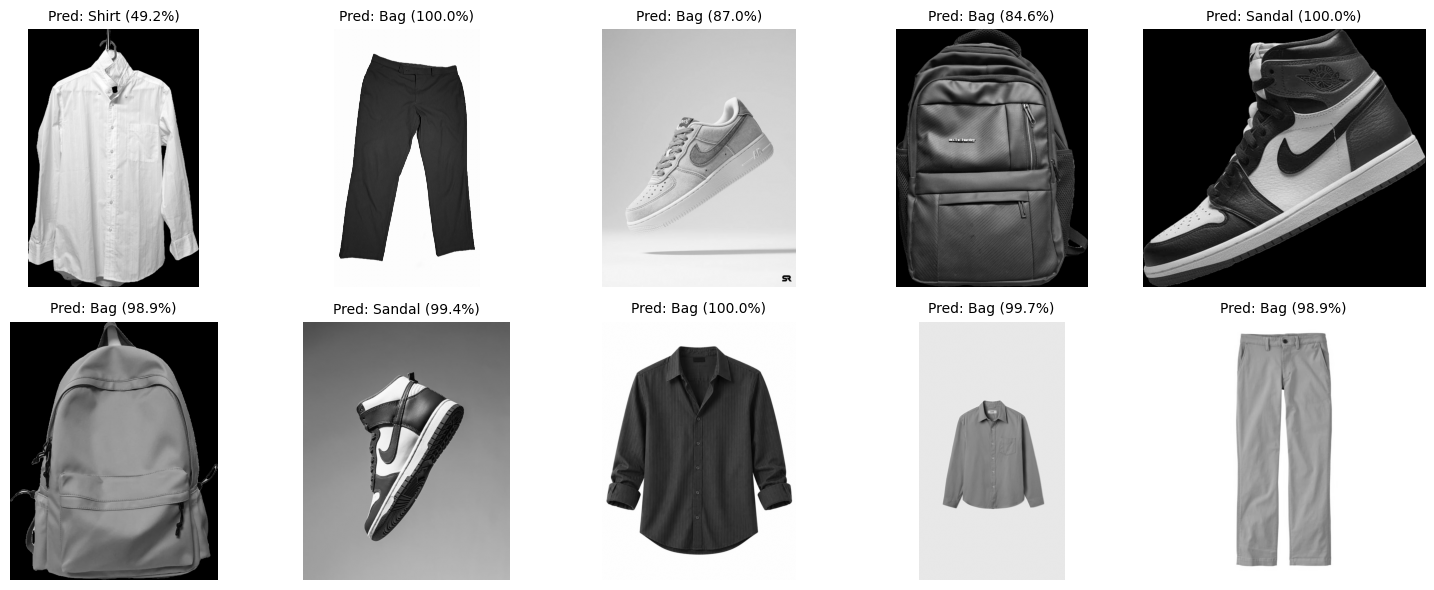

In [29]:
n = len(results)
if n == 0:
    print("No custom images were processed. Please ensure your image files are present in the 'dataset/' folder and the paths in `custom_files` are correct.")
else:
    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, (path, img, pred_class, conf) in zip(axes, results):
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Pred: {pred_class} ({conf:.1f}%)', fontsize=10)
        ax.axis('off')

    for ax in axes[len(results):]:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('custom_prediction_gallery.png')
    plt.show()